## 1. Data Loading

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Walmart_Sales.csv')
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


## 2. Basic Exploration

In [45]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


## 3. Fix Data Types

In [46]:
# Fix date type
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# Ensure Holiday_Flag is integer
df['Holiday_Flag'] = df['Holiday_Flag'].astype(int)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB


## 4. Check Nulls & Duplicates

In [47]:
print('Null values:')
print(df.isnull().sum())
print()
print('Duplicate rows:', df.duplicated().sum())

Null values:
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

Duplicate rows: 0


## 5. Sort by Date

In [48]:
df = df.sort_values('Date').reset_index(drop=True)
print(f'Date range: {df["Date"].min()} to {df["Date"].max()}')
print(f'Unique stores: {df["Store"].nunique()}')
df.head()

Date range: 2010-02-05 00:00:00 to 2012-10-26 00:00:00
Unique stores: 45


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,10,2010-02-05,2193048.75,0,54.34,2.962,126.442065,9.765
2,37,2010-02-05,536006.73,0,45.97,2.572,209.852966,8.554
3,17,2010-02-05,789036.02,0,23.11,2.666,126.442065,6.548
4,30,2010-02-05,465108.52,0,39.05,2.572,210.752605,8.324


## 6. Exploratory Data Analysis

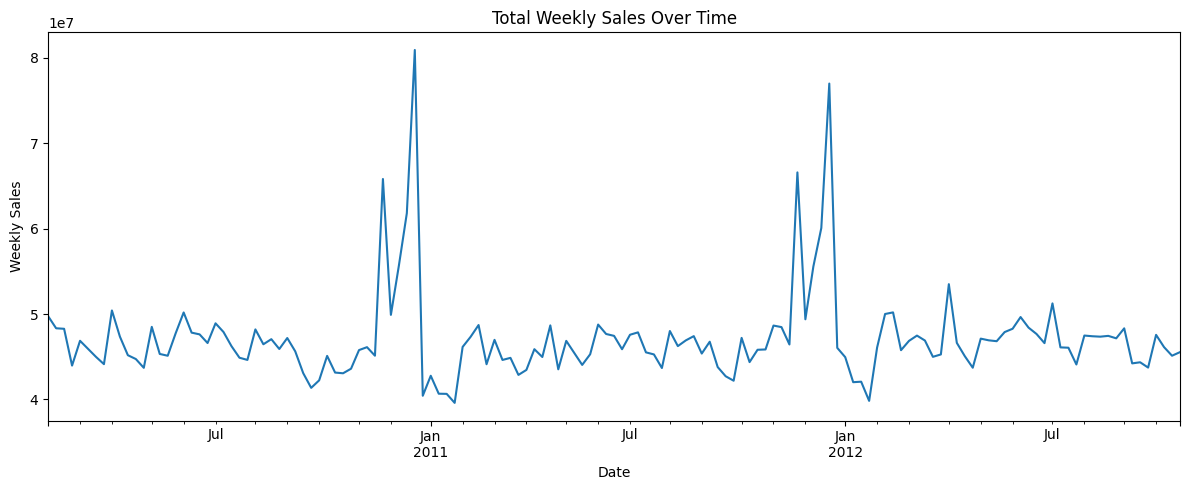

In [49]:
# Overall weekly sales trend
df.groupby('Date')['Weekly_Sales'].sum().plot(figsize=(12, 5), title='Total Weekly Sales Over Time')
plt.ylabel('Weekly Sales')
plt.tight_layout()
plt.show()

In [50]:
# Store-level comparison: best vs worst performing
store_avg = df.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending=False)
print('Top 5 stores by average sales:')
print(store_avg.head())
print()
print('Bottom 5 stores by average sales:')
print(store_avg.tail())

Top 5 stores by average sales:
Store
20    2.107677e+06
4     2.094713e+06
14    2.020978e+06
13    2.003620e+06
2     1.925751e+06
Name: Weekly_Sales, dtype: float64

Bottom 5 stores by average sales:
Store
38    385731.653287
36    373511.992797
5     318011.810490
44    302748.866014
33    259861.692028
Name: Weekly_Sales, dtype: float64


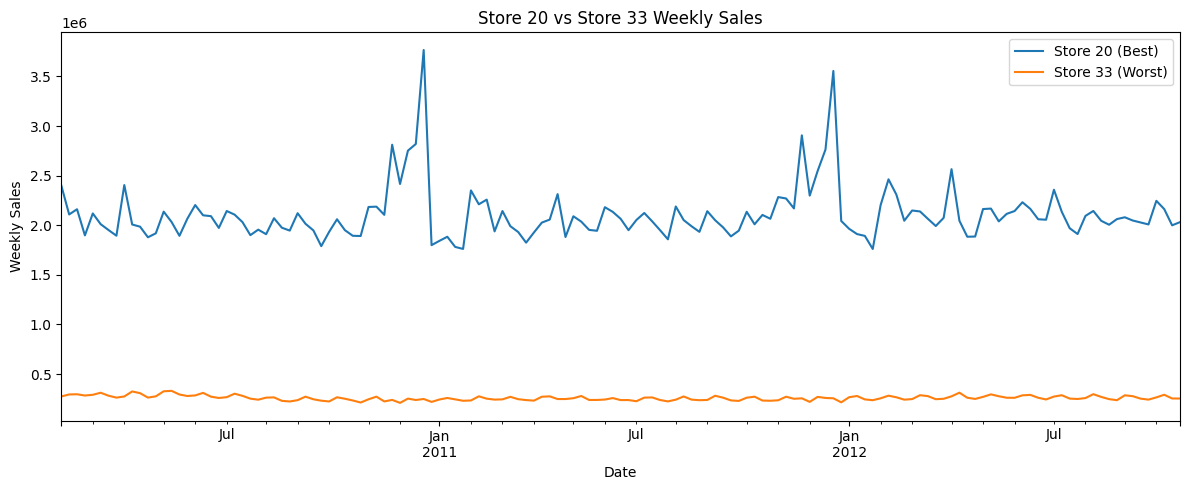

In [51]:
# Best (Store 20) vs Worst (Store 33)
fig, ax = plt.subplots(figsize=(12, 5))
df[df['Store'] == 20].groupby('Date')['Weekly_Sales'].sum().plot(ax=ax, label='Store 20 (Best)')
df[df['Store'] == 33].groupby('Date')['Weekly_Sales'].sum().plot(ax=ax, label='Store 33 (Worst)')
ax.set_title('Store 20 vs Store 33 Weekly Sales')
ax.set_ylabel('Weekly Sales')
plt.legend()
plt.tight_layout()
plt.show()

In [52]:
# Holiday impact
print('Average sales by holiday flag:')
print(df.groupby('Holiday_Flag')['Weekly_Sales'].mean())

Average sales by holiday flag:
Holiday_Flag
0    1.041256e+06
1    1.122888e+06
Name: Weekly_Sales, dtype: float64


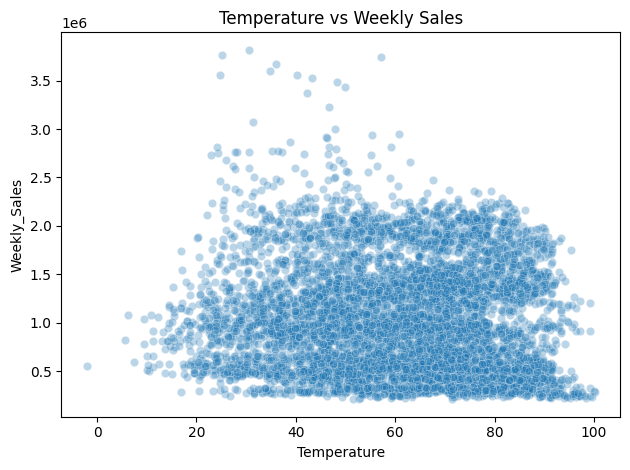

In [53]:
# Temperature vs Sales
sns.scatterplot(x='Temperature', y='Weekly_Sales', data=df, alpha=0.3)
plt.title('Temperature vs Weekly Sales')
plt.tight_layout()
plt.show()

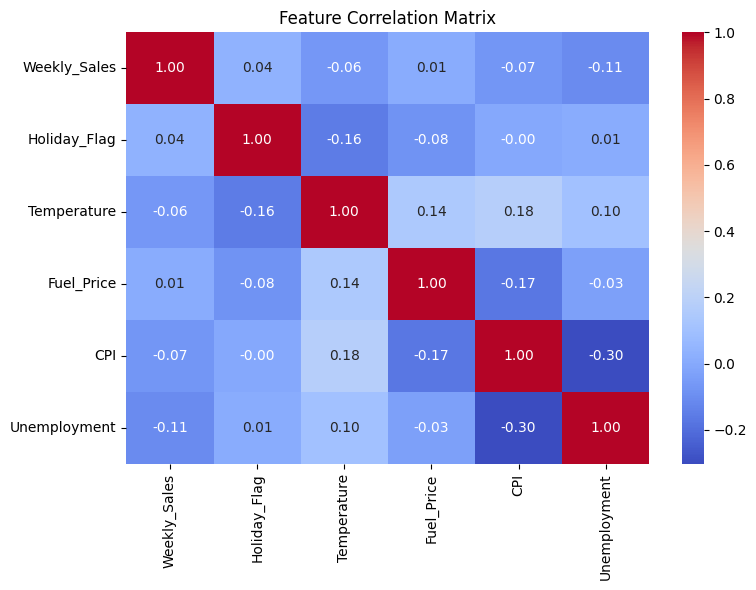

In [54]:
# Correlation heatmap (numeric features only)
numeric_cols = ['Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 7. Train/Test Split FIRST (before feature engineering)

In [55]:
# Split by time — no random split for time series!
split_date = '2012-01-01'
train_raw = df[df['Date'] < split_date].copy()
test_raw  = df[df['Date'] >= split_date].copy()

print(f'Train size: {len(train_raw)} rows ({train_raw["Date"].min().date()} to {train_raw["Date"].max().date()})')
print(f'Test  size: {len(test_raw)} rows ({test_raw["Date"].min().date()} to {test_raw["Date"].max().date()})')

Train size: 4500 rows (2010-02-05 to 2011-12-30)
Test  size: 1935 rows (2012-01-06 to 2012-10-26)


## 8. Time-Based Feature Engineering and Lag Construction

In [56]:
def add_features(data):
    data = data.sort_values(['Store', 'Date']).copy()

    # Temporal features
    data['Year']  = data['Date'].dt.year
    data['Month'] = data['Date'].dt.month
    data['Week']  = data['Date'].dt.isocalendar().week.astype(int)  # Fix: cast UInt32 -> int

    # Lag features (grouped by store to avoid cross-store leakage)
    data['Lag_1'] = data.groupby('Store')['Weekly_Sales'].shift(1)
    data['Lag_2'] = data.groupby('Store')['Weekly_Sales'].shift(2)

    return data

train = add_features(train_raw)
test  = add_features(test_raw)

# Drop rows with NaN lags
train = train.dropna()
test  = test.dropna()

print('Null values in train:', train.isnull().sum().sum())
print('Null values in test:', test.isnull().sum().sum())

Null values in train: 0
Null values in test: 0


## 9. Prepare Features & Labels

In [57]:
X_train = train.drop(['Weekly_Sales', 'Date'], axis=1)
y_train = train['Weekly_Sales']

X_test = test.drop(['Weekly_Sales', 'Date'], axis=1)
y_test = test['Weekly_Sales']

# One-hot encode Store column
X_train = pd.get_dummies(X_train, columns=['Store'], drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=['Store'], drop_first=True)

# Align columns — test may be missing some store dummies
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print(f'X_train shape: {X_train.shape}')
print(f'X_test  shape: {X_test.shape}')

X_train shape: (4410, 54)
X_test  shape: (1845, 54)


## 10. Model 1 — Linear Regression 

In [58]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr  = r2_score(y_test, y_pred_lr)

print(f'Linear Regression — MAE: {mae_lr:,.2f}  |  R²: {r2_lr:.4f}')

Linear Regression — MAE: 74,449.60  |  R²: 0.9655


## 11. Model 2 — Random Forest

In [59]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf  = r2_score(y_test, y_pred_rf)

print(f'Random Forest     — MAE: {mae_rf:,.2f}  |  R²: {r2_rf:.4f}')

Random Forest     — MAE: 57,848.40  |  R²: 0.9767


## 12. Model Comparison

In [60]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE':   [mae_lr, mae_rf],
    'R2':    [r2_lr, r2_rf]
})
print(results.to_string(index=False))

            Model          MAE       R2
Linear Regression 74449.599419 0.965453
    Random Forest 57848.401270 0.976677


## 13. Actual vs Predicted Plot

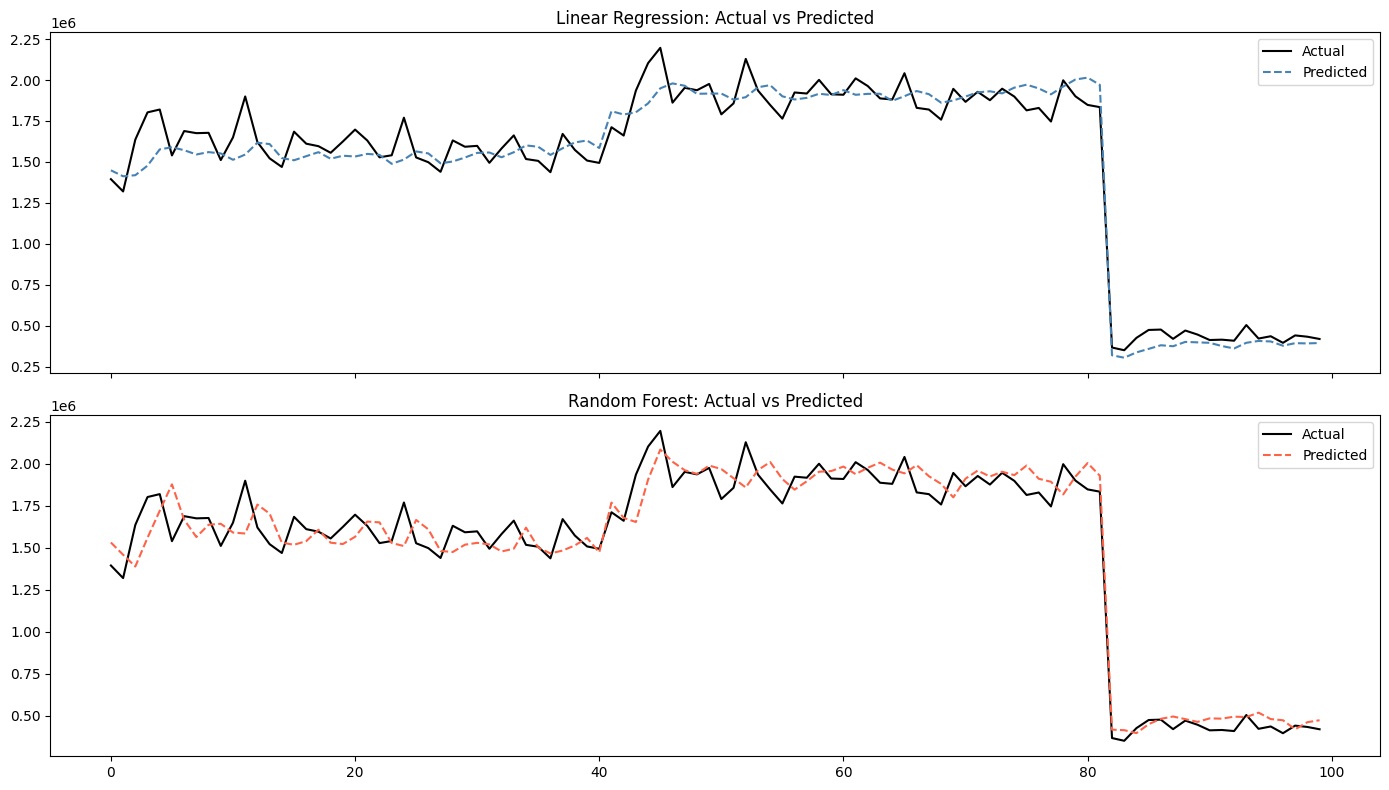

In [61]:
# Show first 100 test samples for readability
n = 100
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(y_test.values[:n], label='Actual', color='black')
axes[0].plot(y_pred_lr[:n],     label='Predicted', color='steelblue', linestyle='--')
axes[0].set_title('Linear Regression: Actual vs Predicted')
axes[0].legend()

axes[1].plot(y_test.values[:n], label='Actual', color='black')
axes[1].plot(y_pred_rf[:n],     label='Predicted', color='tomato', linestyle='--')
axes[1].set_title('Random Forest: Actual vs Predicted')
axes[1].legend()

plt.tight_layout()
plt.show()

## 14. Feature Importance (Random Forest)

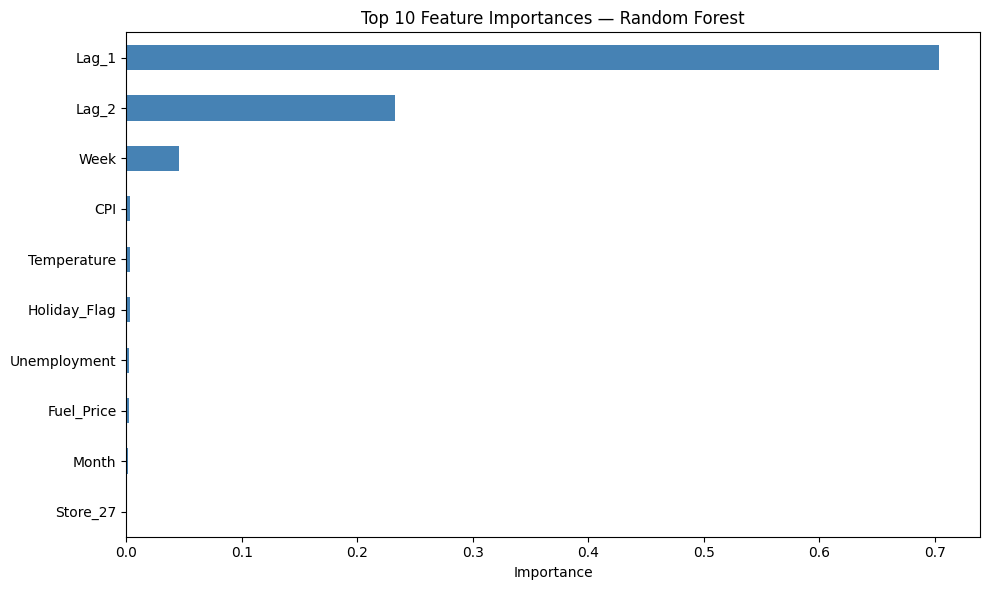

In [62]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top10 = importances.nlargest(10).sort_values()

top10.plot(kind='barh', figsize=(10, 6), color='steelblue')
plt.title('Top 10 Feature Importances — Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()